In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("remote_work_productivity.csv")


sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Hours_Worked_Per_Week",
    y="Well_Being_Score",
    hue="Employment_Type",
    palette={"Remote": "skyblue", "In-Office": "salmon"},
    alpha=0.7,
    edgecolor="w",
    s=100
)

plt.title("Werktijd vs. Welzijnsscore per Werkvorm", fontsize=14)
plt.xlabel("Uren gewerkt per week", fontsize=12)
plt.ylabel("Welzijnsscore", fontsize=12)
plt.legend(title="Werkvorm")
plt.tight_layout()

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'remote_work_productivity.csv'

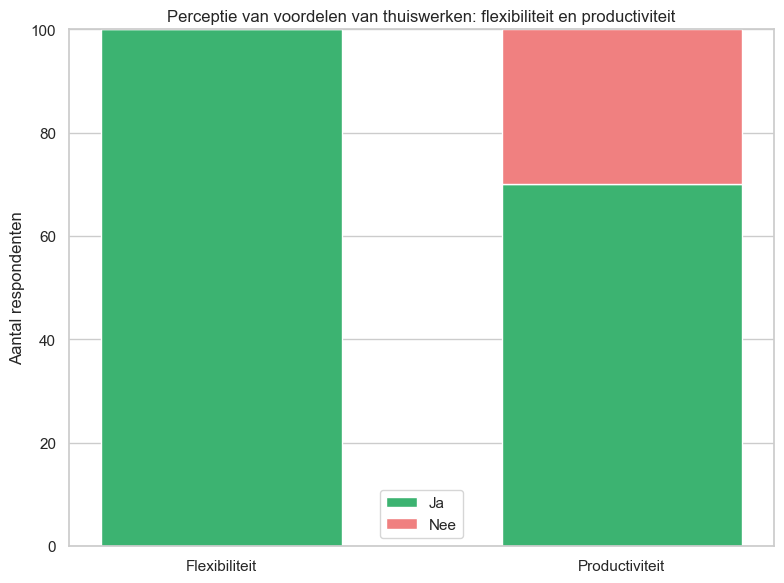

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df_survey = pd.read_csv("survey_remote_work.csv")

cols = [
    "Do you think that working from home gives you more flexibility?",
    "Do you think that working from home increases your work productivity?"
]
labels = [
    "Flexibiliteit", "Productiviteit"
]


yes_counts = [df_survey[col].value_counts().get("Yes", 0) for col in cols]
no_counts = [df_survey[col].value_counts().get("No", 0) for col in cols]


x = np.arange(len(cols))
bar_width = 0.6

plt.figure(figsize=(8, 6))
plt.bar(x, yes_counts, bar_width, label='Ja', color='mediumseagreen')
plt.bar(x, no_counts, bar_width, bottom=yes_counts, label='Nee', color='lightcoral')

plt.xticks(x, labels)
plt.ylabel("Aantal respondenten")
plt.title("Perceptie van voordelen van thuiswerken: flexibiliteit en productiviteit")
plt.legend()
plt.tight_layout()
plt.show()




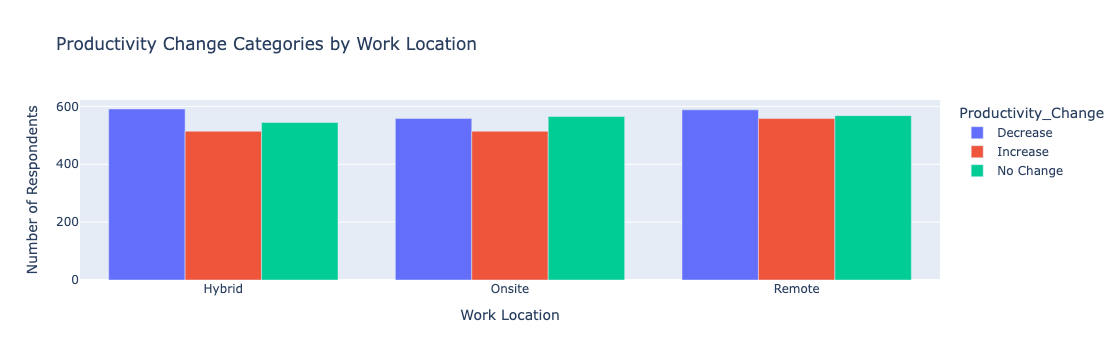

In [20]:
import pandas as pd
import plotly.express as px

# Dataset laden
df = pd.read_csv("remote_work_impact.csv")
import pandas as pd
import plotly.express as px

# Aantal respondenten per Work_Location en Productivity_Change
prod_counts = df.groupby(['Work_Location', 'Productivity_Change']).size().reset_index(name='Count')

fig = px.bar(prod_counts, x='Work_Location', y='Count', color='Productivity_Change',
             title='Productivity Change Categories by Work Location',
             labels={'Work_Location': 'Work Location', 'Count': 'Number of Respondents'},
             barmode='group')
fig.show()



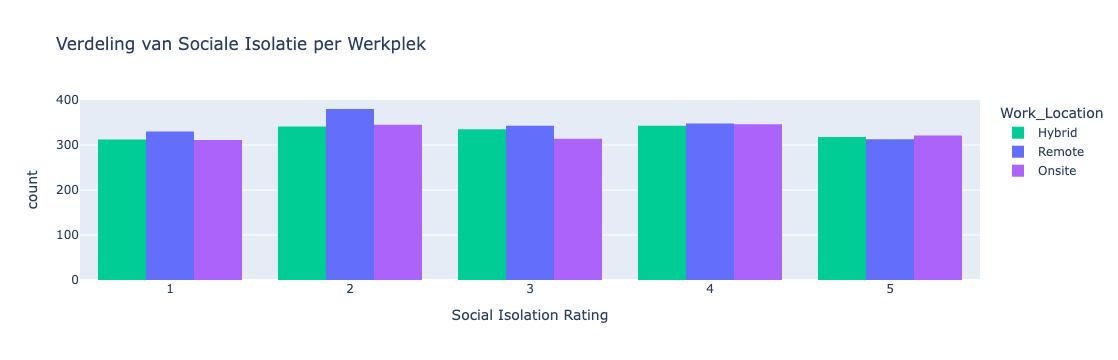

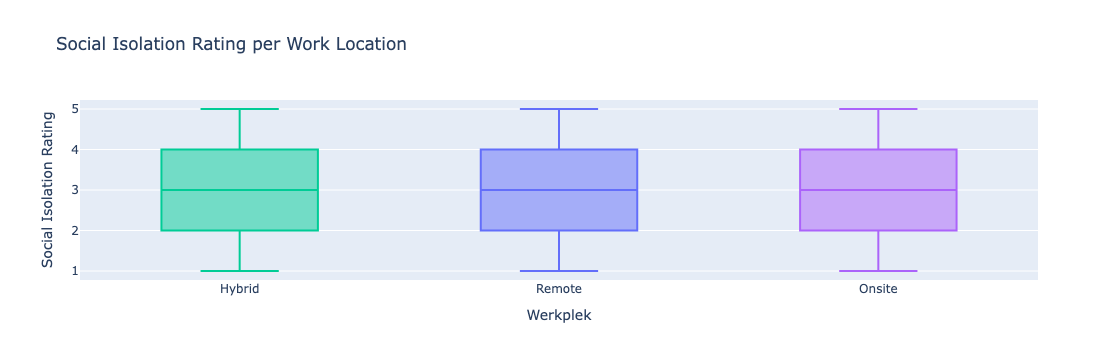

Stress_Level_Num kolom niet gevonden, maak deze eerst numeriek.


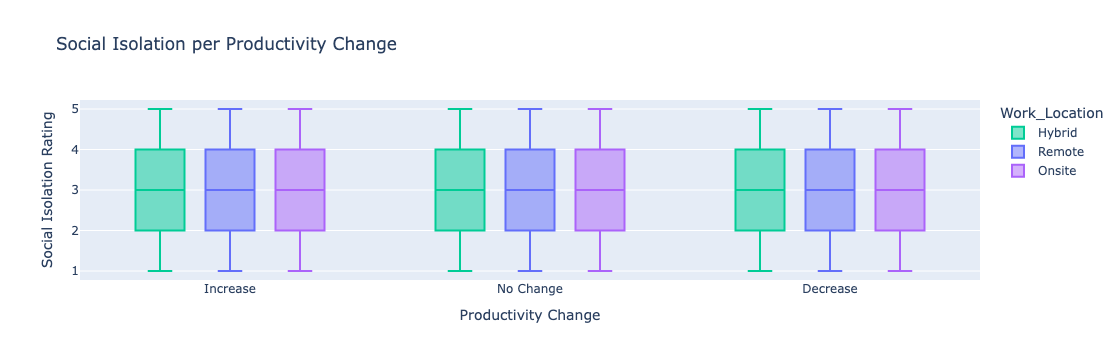

In [12]:
import plotly.express as px

# Verdeling social isolation rating per werkplek
fig1 = px.histogram(df, x='Social_Isolation_Rating', color='Work_Location', barmode='group',
                    title='Verdeling van Sociale Isolatie per Werkplek',
                    labels={'Social_Isolation_Rating': 'Social Isolation Rating',
                            'count': 'Aantal Respondenten'},
                    color_discrete_map={'Remote': '#636EFA', 'Office': '#EF553B'})
fig1.show()


# Boxplot: Social Isolation per Work Location
fig2 = px.box(df, x='Work_Location', y='Social_Isolation_Rating',
              color='Work_Location',
              title='Social Isolation Rating per Work Location',
              labels={'Social_Isolation_Rating': 'Social Isolation Rating', 'Work_Location': 'Werkplek'},
              color_discrete_map={'Remote': '#636EFA', 'Office': '#EF553B'})
fig2.update_layout(showlegend=False)
fig2.show()


# Scatterplot Social Isolation vs Stress Level (indien Stress_Level al numeriek is)
if 'Stress_Level_Num' in df.columns:
    fig3 = px.scatter(df, x='Social_Isolation_Rating', y='Stress_Level_Num', color='Work_Location',
                      title='Social Isolation vs Stress Level',
                      labels={'Social_Isolation_Rating': 'Social Isolation Rating',
                              'Stress_Level_Num': 'Stress Level'},
                      color_discrete_map={'Remote': '#636EFA', 'Office': '#EF553B'},
                      trendline='ols')
    fig3.show()
else:
    print("Stress_Level_Num kolom niet gevonden, maak deze eerst numeriek.")


# Boxplot: Social Isolation per Productivity Change
fig4 = px.box(df, x='Productivity_Change', y='Social_Isolation_Rating',
              color='Work_Location',
              title='Social Isolation per Productivity Change',
              labels={'Productivity_Change': 'Productivity Change', 'Social_Isolation_Rating': 'Social Isolation Rating'},
              category_orders={'Productivity_Change': ['Increase', 'No Change', 'Decrease']},
              color_discrete_map={'Remote': '#636EFA', 'Office': '#EF553B'})
fig4.show()
